# Lab 01: Build Your First GAN

**Goal:** Build a GAN that learns to generate the number 7 — without ever seeing it.

**What you'll do:**
- Build a Generator and Discriminator from scratch
- Train them against each other
- Watch G discover the number 7 on its own
- Visualize loss curves and learn to read them
- Experiment: change targets, learning rates, learn a distribution

**Time:** ~45 minutes

---

## Part 1: Setup

In [1]:
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

torch.manual_seed(42)

print(f"PyTorch version: {torch.__version__}")

PyTorch version: 2.12.1+cpu


---
## Part 2: Build the Generator

**What is it?**
- A small neural network that takes random noise and produces a number
- Right now it knows nothing — output will be garbage
- After training, it should output numbers close to 7

**Architecture:**
- Input: 1 random number (noise)
- Hidden: 16 neurons + ReLU activation
- Output: 1 number (the fake output)

```
noise (1) --> [Linear 16] --> [ReLU] --> [Linear 1] --> fake number
```

In [2]:
generator = nn.Sequential(
    nn.Linear(1, 16),
    nn.ReLU(),
    nn.Linear(16, 1),
)

print("Generator:")
print(generator)
print(f"Parameters: {sum(p.numel() for p in generator.parameters())}")

Generator:
Sequential(
  (0): Linear(in_features=1, out_features=16, bias=True)
  (1): ReLU()
  (2): Linear(in_features=16, out_features=1, bias=True)
)
Parameters: 49


**Test G before training:**
- Feed 5 different random noise values
- G should output random garbage — it hasn't learned anything yet
- None of these will be close to 7

In [3]:
print("Generator output BEFORE training:")
with torch.no_grad():
    for i in range(5):
        noise = torch.randn(1, 1)
        output = generator(noise).item()
        print(f"  Noise: {noise.item():+.4f}  -->  Output: {output:+.4f}")

print("\nAll garbage. G doesn't know 7 exists yet.")

Generator output BEFORE training:
  Noise: -1.0186  -->  Output: +0.1643
  Noise: -0.4180  -->  Output: +0.2824
  Noise: -0.2935  -->  Output: +0.3036
  Noise: +1.4329  -->  Output: +1.2314
  Noise: +0.5312  -->  Output: +0.6730

All garbage. G doesn't know 7 exists yet.


---
## Part 3: Build the Discriminator

**What is it?**
- A classifier — looks at a number and says real (1) or fake (0)
- Same idea as the classifier from Lab P3
- Sigmoid at the end squashes output to 0-1 range (probability)

**Architecture:**
- Input: 1 number (could be real or fake)
- Hidden: 16 neurons + ReLU
- Output: 1 probability (0 = fake, 1 = real)

```
number --> [Linear 16] --> [ReLU] --> [Linear 1] --> [Sigmoid] --> 0 to 1
```

In [4]:
discriminator = nn.Sequential(
    nn.Linear(1, 16),
    nn.ReLU(),
    nn.Linear(16, 1),
    nn.Sigmoid(),
)

print("Discriminator:")
print(discriminator)
print(f"Parameters: {sum(p.numel() for p in discriminator.parameters())}")

Discriminator:
Sequential(
  (0): Linear(in_features=1, out_features=16, bias=True)
  (1): ReLU()
  (2): Linear(in_features=16, out_features=1, bias=True)
  (3): Sigmoid()
)
Parameters: 49


**Test D before training:**
- Give it the real value (7.0) and a fake value (2.3)
- Both should be around 0.5 — D can't tell the difference yet
- After training, D should say ~1.0 for real and ~0.0 for fake

In [5]:
with torch.no_grad():
    real = discriminator(torch.tensor([[7.0]])).item()
    fake = discriminator(torch.tensor([[2.3]])).item()

print(f"D on real data (7.0): {real:.4f}")
print(f"D on fake data (2.3): {fake:.4f}")
print(f"\nBoth around 0.5 -- D can't tell the difference yet.")

D on real data (7.0): 0.2181
D on fake data (2.3): 0.3525

Both around 0.5 -- D can't tell the difference yet.


---
## Part 4: Loss and Optimizers

**What we need before training:**
- **BCE Loss** — measures how wrong D's "real or fake" answers are
- **Two separate optimizers** — G and D learn independently, they take turns
- **Labels** — real_label = 1.0 ("this is real"), fake_label = 0.0 ("this is fake")

In [6]:
loss_fn = nn.BCELoss()

gen_optimizer = torch.optim.Adam(generator.parameters(), lr=0.001)
dis_optimizer = torch.optim.Adam(discriminator.parameters(), lr=0.001)

real_label = torch.tensor([[1.0]])   # "this is real"
fake_label = torch.tensor([[0.0]])   # "this is fake"

print("Ready to train!")

Ready to train!


---
## Part 5: Train the GAN

**This is the core of every GAN — two steps repeated 2000 times:**

**Step A — Train Discriminator:**
- Show D real data (7.0) — D should say 1
- Show D fake data (from G) — D should say 0
- `.detach()` on fake data — so only D learns, G stays frozen
- Update D's weights

**Step B — Train Generator:**
- G creates fake data from random noise
- D judges it
- G wants D to say 1 ("fooled!") — so G uses `real_label`
- NO `.detach()` — gradients flow back to G so it can learn
- Update G's weights

**What to watch in the output:**
- `Generated` column — should move from garbage toward 7.0
- `D_loss` and `G_loss` — should stay in similar range (neither drops to 0)

In [7]:
gen_losses = []
dis_losses = []
generated_values = []

for epoch in range(1, 2001):

    # ====== Step A: Train Discriminator ======

    # Real data: D should say 1
    real_data = torch.tensor([[7.0]])
    real_pred = discriminator(real_data)
    loss_real = loss_fn(real_pred, real_label)

    # Fake data: D should say 0
    noise = torch.randn(1, 1)
    fake_data = generator(noise).detach()     # .detach() = only D learns
    fake_pred = discriminator(fake_data)
    loss_fake = loss_fn(fake_pred, fake_label)

    # Update D
    dis_loss = loss_real + loss_fake
    dis_optimizer.zero_grad()
    dis_loss.backward()
    dis_optimizer.step()

    # ====== Step B: Train Generator ======

    # G makes fake, wants D to say 1
    noise = torch.randn(1, 1)
    fake_data = generator(noise)              # NO detach = G learns
    fake_pred = discriminator(fake_data)
    gen_loss = loss_fn(fake_pred, real_label)  # G wants D to say "real"

    # Update G
    gen_optimizer.zero_grad()
    gen_loss.backward()
    gen_optimizer.step()

    # ====== Track progress ======
    gen_losses.append(gen_loss.item())
    dis_losses.append(dis_loss.item())

    with torch.no_grad():
        generated_values.append(generator(torch.randn(1, 1)).item())

    if epoch in [1, 50, 100, 250, 500, 1000, 1500, 2000]:
        print(f"Epoch {epoch:4d}:  D_loss={dis_loss.item():.4f}  "
              f"G_loss={gen_loss.item():.4f}  "
              f"Generated={generated_values[-1]:.4f}")

print("\nTraining complete!")

Epoch    1:  D_loss=1.9760  G_loss=0.9863  Generated=0.4143
Epoch   50:  D_loss=1.1064  G_loss=0.9330  Generated=0.6860
Epoch  100:  D_loss=0.8229  G_loss=0.8907  Generated=0.5788
Epoch  250:  D_loss=0.5791  G_loss=0.6914  Generated=0.9357
Epoch  500:  D_loss=1.8574  G_loss=0.4098  Generated=5.8136
Epoch 1000:  D_loss=1.3988  G_loss=0.8766  Generated=8.6324
Epoch 1500:  D_loss=1.3799  G_loss=1.0868  Generated=7.2485
Epoch 2000:  D_loss=1.3854  G_loss=0.7019  Generated=6.9203

Training complete!


---
## Part 6: Visualize the Training

**Two plots to understand what happened:**
- **Left plot:** G loss vs D loss — healthy if both stay in similar range
- **Right plot:** what G outputs over time — should climb toward the red line (7.0)
- If G's output reaches 7.0, it means G learned to produce the target

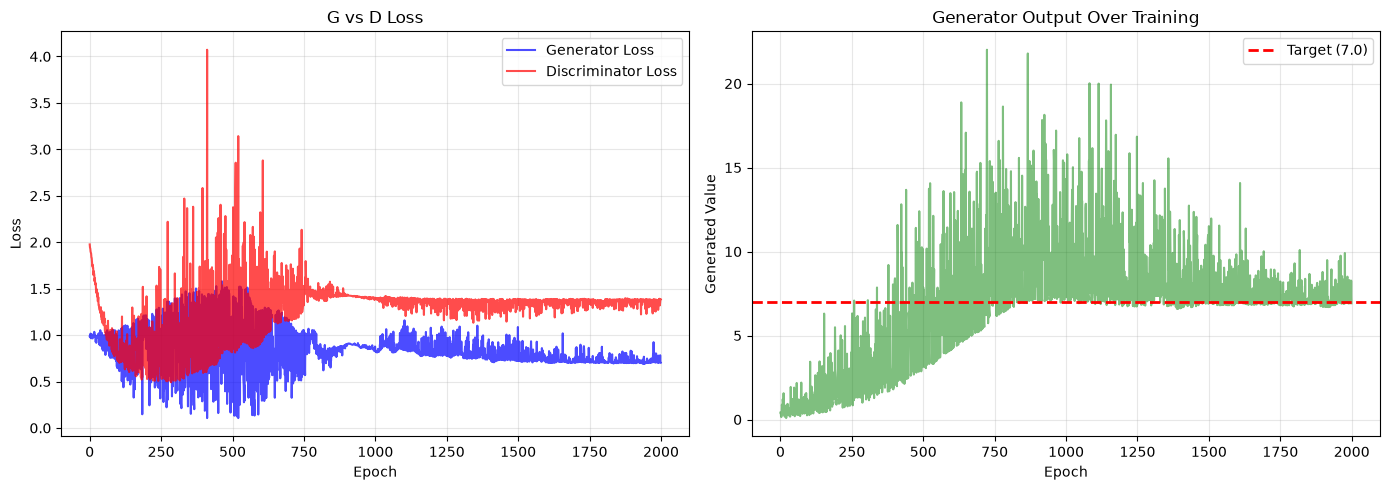

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(gen_losses, label='Generator Loss', alpha=0.7, color='blue')
axes[0].plot(dis_losses, label='Discriminator Loss', alpha=0.7, color='red')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].set_title('G vs D Loss')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(generated_values, color='green', alpha=0.5)
axes[1].axhline(y=7.0, color='red', linestyle='--', linewidth=2, label='Target (7.0)')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Generated Value')
axes[1].set_title('Generator Output Over Training')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

**How to read GAN loss curves:**

| What you see | What it means | Good or bad? |
|---|---|---|
| Both losses stay in similar range | G and D are balanced | Good |
| D_loss drops to 0 | D too strong, G gets no feedback | Bad |
| G_loss stays flat and high | G is stuck, not improving | Bad |
| Wild up-and-down swinging | Learning rate too high | Bad |

**Smoothed curves below** — removes noise, easier to see the trend:

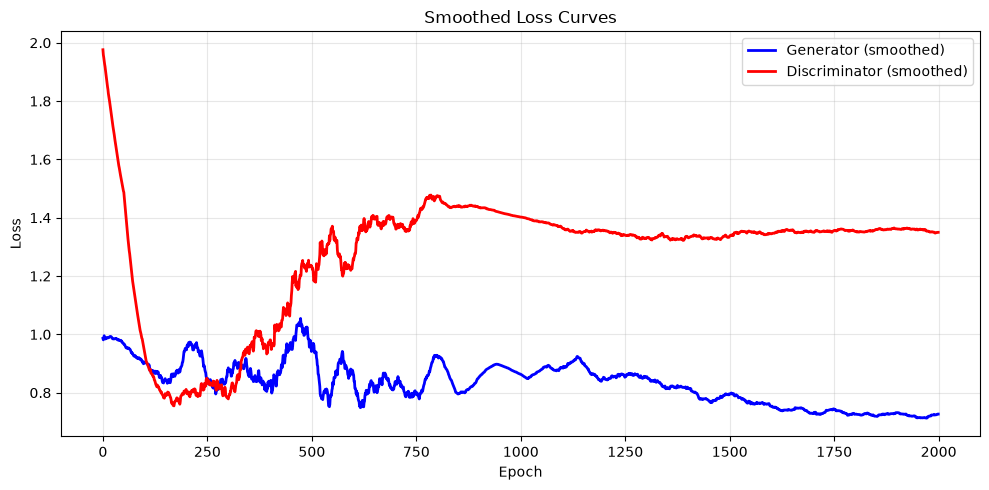

In [9]:
def smooth(values, window=50):
    smoothed = []
    for i in range(len(values)):
        start = max(0, i - window)
        smoothed.append(sum(values[start:i+1]) / (i - start + 1))
    return smoothed

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(smooth(gen_losses), label='Generator (smoothed)', color='blue', linewidth=2)
ax.plot(smooth(dis_losses), label='Discriminator (smoothed)', color='red', linewidth=2)
ax.set_xlabel('Epoch')
ax.set_ylabel('Loss')
ax.set_title('Smoothed Loss Curves')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

---
## Part 7: Test the Trained Generator

**G is now trained. Let's see what it produces:**
- Generate 20 samples, each from different random noise
- All outputs should be close to 7 (but not exactly — slight variation is normal)
- Different noise = different output, but all near the same target

In [10]:
print("20 samples from the trained Generator:")
print("=" * 40)

samples = []
with torch.no_grad():
    for i in range(20):
        value = generator(torch.randn(1, 1)).item()
        samples.append(value)
        print(f"  Sample {i+1:2d}: {value:.4f}")

print(f"\n  Mean:   {sum(samples)/len(samples):.4f}")
print(f"  Target: 7.0000")

20 samples from the trained Generator:
  Sample  1: 6.9779
  Sample  2: 7.0380
  Sample  3: 7.0449
  Sample  4: 6.9426
  Sample  5: 7.0903
  Sample  6: 6.9565
  Sample  7: 7.0724
  Sample  8: 7.0684
  Sample  9: 7.0159
  Sample 10: 6.9781
  Sample 11: 6.8974
  Sample 12: 7.4424
  Sample 13: 6.8978
  Sample 14: 7.8781
  Sample 15: 7.8836
  Sample 16: 6.9160
  Sample 17: 6.9624
  Sample 18: 7.6626
  Sample 19: 7.4834
  Sample 20: 8.1283

  Mean:   7.2168
  Target: 7.0000


**Histogram of 1000 samples:**
- Blue bars = G's outputs
- Red dashed line = target (7.0)
- Should be a tight cluster around 7.0

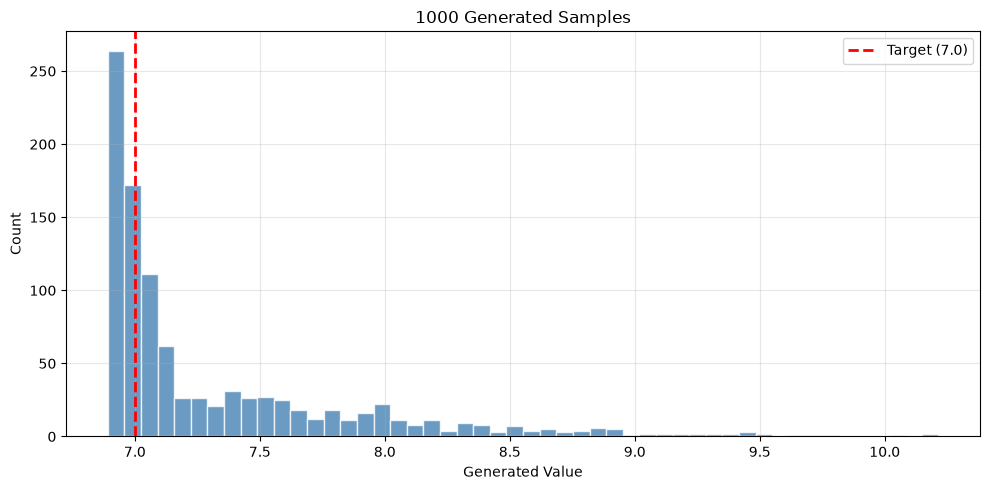

Mean: 7.3245
Std:  0.5699


In [12]:
with torch.no_grad():
    all_samples = [generator(torch.randn(1, 1)).item() for _ in range(1000)]

fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(all_samples, bins=50, color='steelblue', edgecolor='white', alpha=0.8)
ax.axvline(x=7.0, color='red', linestyle='--', linewidth=2, label='Target (7.0)')
ax.set_xlabel('Generated Value')
ax.set_ylabel('Count')
ax.set_title('1000 Generated Samples')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

import numpy as np
print(f"Mean: {np.mean(all_samples):.4f}")
print(f"Std:  {np.std(all_samples):.4f}")

---
## Part 8: Understand .detach()

**The most important trick in GAN training:**
- `.detach()` cuts the gradient chain — stops G from learning
- In Step A (train D): use `.detach()` so only D updates
- In Step B (train G): do NOT use `.detach()` so G can learn from D's feedback
- Without this, both would update at the same time = chaos

In [13]:
noise = torch.randn(1, 1)

# WITH detach: gradient chain is broken
fake_detached = generator(noise).detach()
print(f"With .detach():    requires_grad = {fake_detached.requires_grad}")

# WITHOUT detach: gradient chain is intact
fake_connected = generator(noise)
print(f"Without .detach(): requires_grad = {fake_connected.requires_grad}")

print("\nStep A (train D): use .detach()  --> only D learns")
print("Step B (train G): no .detach()   --> G learns from D's feedback")

With .detach():    requires_grad = False
Without .detach(): requires_grad = True

Step A (train D): use .detach()  --> only D learns
Step B (train G): no .detach()   --> G learns from D's feedback


---
## Part 9: The Adversarial Game in Numbers

**Let's check what D thinks after training:**
- D on real data (7.0) — should be close to 1.0 ("I think it's real")
- D on G's output — if close to 0.5, it means D can't tell = G has won
- If D on fake is close to 0.0, D is still winning

In [14]:
with torch.no_grad():
    noise = torch.randn(1, 1)
    fake = generator(noise)
    d_on_real = discriminator(torch.tensor([[7.0]])).item()
    d_on_fake = discriminator(fake).item()

print("The adversarial game right now:")
print(f"  D on real data (7.0):         {d_on_real:.4f}")
print(f"  D on fake data ({fake.item():.2f}):       {d_on_fake:.4f}")
print(f"")
print(f"  D is {'fooled' if d_on_fake > 0.4 else 'not fooled'} "
      f"(values near 0.5 = D can't tell the difference)")

The adversarial game right now:
  D on real data (7.0):         0.4949
  D on fake data (7.30):       0.4836

  D is fooled (values near 0.5 = D can't tell the difference)


---
## Part 10: Experiments

### Experiment 1: Change the target number

**Question:** Can G learn ANY number, not just 7?
- We train 4 separate GANs with targets: 3, 7, 15, -5
- Each one starts from scratch
- Watch which converge and how fast
- Larger/negative numbers might be harder

In [15]:
def train_gan_for_target(target, epochs=2000):
    G = nn.Sequential(nn.Linear(1, 16), nn.ReLU(), nn.Linear(16, 1))
    D = nn.Sequential(nn.Linear(1, 16), nn.ReLU(), nn.Linear(16, 1), nn.Sigmoid())
    loss_fn = nn.BCELoss()
    g_opt = torch.optim.Adam(G.parameters(), lr=0.001)
    d_opt = torch.optim.Adam(D.parameters(), lr=0.001)
    real_lbl = torch.tensor([[1.0]])
    fake_lbl = torch.tensor([[0.0]])
    history = []

    for epoch in range(1, epochs + 1):
        d_loss = loss_fn(D(torch.tensor([[target]])), real_lbl) + \
                 loss_fn(D(G(torch.randn(1, 1)).detach()), fake_lbl)
        d_opt.zero_grad(); d_loss.backward(); d_opt.step()

        g_loss = loss_fn(D(G(torch.randn(1, 1))), real_lbl)
        g_opt.zero_grad(); g_loss.backward(); g_opt.step()

        with torch.no_grad():
            history.append(G(torch.randn(1, 1)).item())
    return history

targets = [3.0, 7.0, 15.0, -5.0]
results = {}
for t in targets:
    print(f"Training for target = {t}...")
    results[t] = train_gan_for_target(t)
print("Done!")

Training for target = 3.0...
Training for target = 7.0...
Training for target = 15.0...
Training for target = -5.0...
Done!


**Results:**
- Each colored line = one GAN learning its target
- Dashed lines = the target values
- Lines should approach their matching dashed line

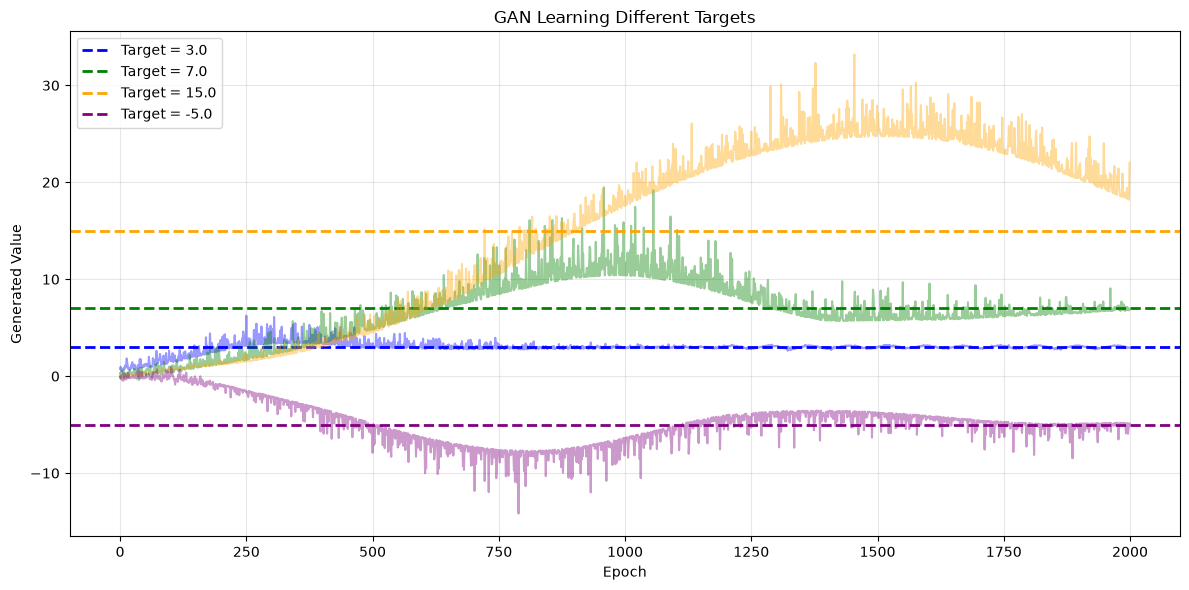

Final values:
  Target   +3.0 --> Generated +2.9268
  Target   +7.0 --> Generated +6.8878
  Target  +15.0 --> Generated +22.0190
  Target   -5.0 --> Generated -4.8858


In [16]:
fig, ax = plt.subplots(figsize=(12, 6))
colors = ['blue', 'green', 'orange', 'purple']
for (target, history), color in zip(results.items(), colors):
    ax.plot(history, alpha=0.4, color=color)
    ax.axhline(y=target, linestyle='--', color=color, linewidth=2,
               label=f'Target = {target}')

ax.set_xlabel('Epoch')
ax.set_ylabel('Generated Value')
ax.set_title('GAN Learning Different Targets')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("Final values:")
for target, history in results.items():
    print(f"  Target {target:+6.1f} --> Generated {history[-1]:+.4f}")

**Question:** Which target was hardest to learn? Why?

---

### Experiment 2: Learning Rate Balance

**The most important setting in GAN training:**
- Balanced LR = stable training
- D too fast = D wins easily, G gets no useful feedback, stays stuck
- G too fast = G finds shortcuts, quality drops
- Both too slow = eventually works but takes forever

**We test 4 combinations:**

In [17]:
def train_gan_with_lr(lr_g, lr_d, epochs=2000):
    G = nn.Sequential(nn.Linear(1, 16), nn.ReLU(), nn.Linear(16, 1))
    D = nn.Sequential(nn.Linear(1, 16), nn.ReLU(), nn.Linear(16, 1), nn.Sigmoid())
    loss_fn = nn.BCELoss()
    g_opt = torch.optim.Adam(G.parameters(), lr=lr_g)
    d_opt = torch.optim.Adam(D.parameters(), lr=lr_d)
    values = []

    for epoch in range(1, epochs + 1):
        d_loss = loss_fn(D(torch.tensor([[7.0]])), torch.tensor([[1.0]])) + \
                 loss_fn(D(G(torch.randn(1, 1)).detach()), torch.tensor([[0.0]]))
        d_opt.zero_grad(); d_loss.backward(); d_opt.step()

        g_loss = loss_fn(D(G(torch.randn(1, 1))), torch.tensor([[1.0]]))
        g_opt.zero_grad(); g_loss.backward(); g_opt.step()

        with torch.no_grad():
            values.append(G(torch.randn(1, 1)).item())
    return values

experiments = {
    'Balanced (G=0.001, D=0.001)':    (0.001, 0.001),
    'Fast D (G=0.001, D=0.01)':       (0.001, 0.01),
    'Fast G (G=0.01, D=0.001)':       (0.01, 0.001),
    'Both slow (G=0.0001, D=0.0001)': (0.0001, 0.0001),
}

lr_results = {}
for name, (lr_g, lr_d) in experiments.items():
    print(f"Training: {name}...")
    lr_results[name] = train_gan_with_lr(lr_g, lr_d)
print("Done!")

Training: Balanced (G=0.001, D=0.001)...
Training: Fast D (G=0.001, D=0.01)...
Training: Fast G (G=0.01, D=0.001)...
Training: Both slow (G=0.0001, D=0.0001)...
Done!


**Compare the 4 combinations:**
- Green line = G's output over time
- Red dashed line = target (7.0)
- Bottom-right corner = final value

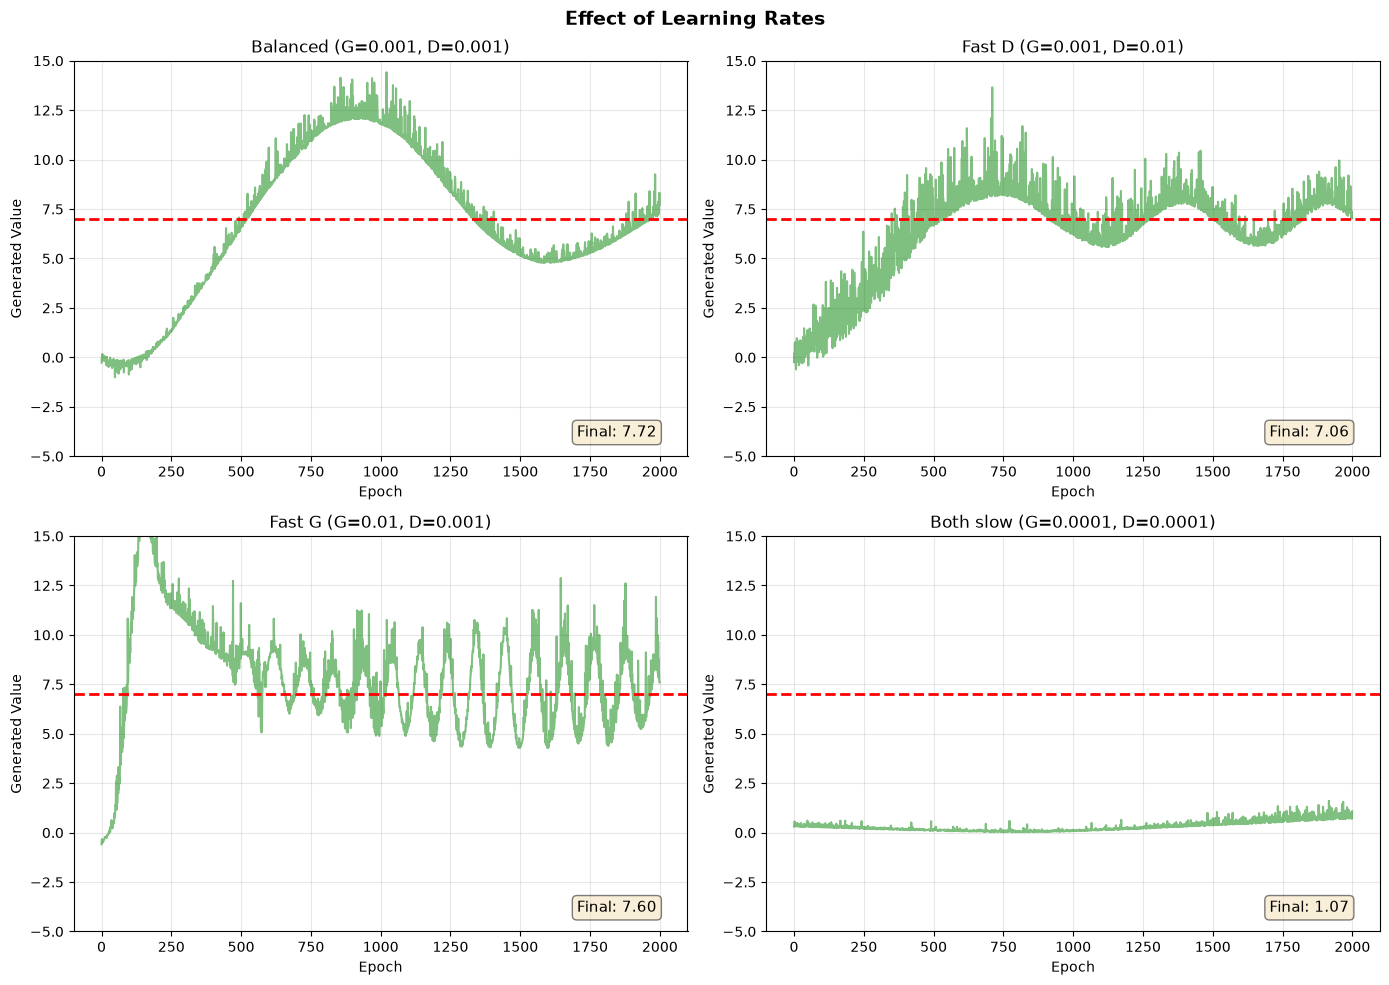

In [18]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

for ax, (name, values) in zip(axes.flat, lr_results.items()):
    ax.plot(values, alpha=0.5, color='green')
    ax.axhline(y=7.0, color='red', linestyle='--', linewidth=2)
    ax.set_title(name)
    ax.set_xlabel('Epoch')
    ax.set_ylabel('Generated Value')
    ax.set_ylim(-5, 15)
    ax.grid(True, alpha=0.3)
    ax.text(0.95, 0.05, f'Final: {values[-1]:.2f}',
            transform=ax.transAxes, ha='right', fontsize=11,
            bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

plt.suptitle('Effect of Learning Rates', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

**What to notice:**
- **Balanced:** reaches 7 quickly and stays there
- **D too fast:** D dominates, G output stays random (no learning signal)
- **G too fast:** may overshoot or oscillate
- **Both slow:** works but needs many more epochs

**Takeaway:** LR balance between G and D is the #1 most important setting.

---

### Experiment 3: Learn a Distribution

**So far:** G learned a single number (7.0)  
**Real GANs:** learn a whole distribution — a SHAPE of data, not a single point

**What we do here:**
- Real data = random numbers around 7 (bell curve: some 5s, some 9s, mostly 7s)
- G should learn this entire spread, not just the center
- We save snapshots at 6 time points to watch it improve
- This is exactly what image GANs do — learn the "shape" of real images

In [19]:
G = nn.Sequential(nn.Linear(1, 32), nn.ReLU(), nn.Linear(32, 1))
D = nn.Sequential(nn.Linear(1, 32), nn.ReLU(), nn.Linear(32, 1), nn.Sigmoid())

loss_fn = nn.BCELoss()
g_opt = torch.optim.Adam(G.parameters(), lr=0.001)
d_opt = torch.optim.Adam(D.parameters(), lr=0.001)

snapshots = {}

for epoch in range(1, 5001):
    batch_size = 64

    # Real data: bell curve centered at 7
    real_data = torch.randn(batch_size, 1) + 7.0
    real_labels = torch.ones(batch_size, 1)
    fake_labels = torch.zeros(batch_size, 1)

    # Train D
    noise = torch.randn(batch_size, 1)
    d_loss = loss_fn(D(real_data), real_labels) + \
             loss_fn(D(G(noise).detach()), fake_labels)
    d_opt.zero_grad(); d_loss.backward(); d_opt.step()

    # Train G
    noise = torch.randn(batch_size, 1)
    g_loss = loss_fn(D(G(noise)), real_labels)
    g_opt.zero_grad(); g_loss.backward(); g_opt.step()

    if epoch in [1, 100, 500, 1000, 3000, 5000]:
        with torch.no_grad():
            snapshots[epoch] = G(torch.randn(1000, 1)).squeeze().numpy()
        print(f"Epoch {epoch:4d}: D_loss={d_loss.item():.4f}  G_loss={g_loss.item():.4f}")

print("Done!")

Epoch    1: D_loss=1.8105  G_loss=0.7505
Epoch  100: D_loss=0.6315  G_loss=0.9068
Epoch  500: D_loss=1.5473  G_loss=0.8686
Epoch 1000: D_loss=1.3925  G_loss=0.5841
Epoch 3000: D_loss=1.3880  G_loss=0.6592
Epoch 5000: D_loss=1.3756  G_loss=0.6736
Done!


**Watch G learn the shape of the data:**
- Blue bars = 1000 samples from G at that epoch
- Red line = the real distribution (bell curve centered at 7)
- Early: G's outputs are scattered randomly
- Later: G's output matches the real bell curve
- **Key insight:** GANs learn DATA SHAPES, not single values

In [ ]:
import numpy as np

fig, axes = plt.subplots(2, 3, figsize=(15, 8))

x_range = np.linspace(2, 12, 200)
true_curve = np.exp(-0.5 * (x_range - 7)**2) / np.sqrt(2 * np.pi)

for ax, (epoch, samples) in zip(axes.flat, snapshots.items()):
    ax.hist(samples, bins=50, density=True, alpha=0.6, color='steelblue',
            edgecolor='white', label='Generated')
    ax.plot(x_range, true_curve, 'r-', linewidth=2, label='Real distribution')
    ax.set_title(f'Epoch {epoch}', fontsize=12)
    ax.set_xlim(2, 12)
    ax.set_ylim(0, 0.8)
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

plt.suptitle('GAN Learning a Bell Curve Distribution', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

**Why this matters:**
- G didn't just learn ONE number — it learned the SHAPE of the data
- For images: G learns what real images look like (edges, textures, shapes)
- Then creates NEW images that fit that pattern
- This is the real power of GANs

---

## Part 11: Summary

| What you did | What it means |
|---|---|
| Built G and D | Two networks that compete |
| `.detach()` in Step A | Only D learns, G stays frozen |
| No `.detach()` in Step B | G learns from D's feedback |
| G uses `real_label` | G wants to fool D into saying "real" |
| Loss curves stay similar | Healthy training — neither side dominates |
| G learned 7 without seeing it | Learned purely through D's feedback |
| LR balance matters most | D too fast = G can't learn |
| Distribution experiment | GANs learn data shapes, not single values |

**Next lab:** Scale from 1 number to **784 pixels** — generate handwritten digit images!